Part 1: Setup - Data and Model
Train size: 35
Validation size: 7

Initial parameters:
  Weight: 0.3367 (true: 0.7)
  Bias: 0.1288 (true: 0.3)

Part 2: Loss Function and Optimizer
Loss function: MSELoss (Mean Squared Error)


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optimizer: SGD (learning rate=0.01)

Initial training loss: 0.0922

Part 3: The 5-Step Training Loop

One training step:
1. Forward pass - predictions shape: torch.Size([35, 1])
2. Calculate loss - loss value: 0.0922
3. Zero gradients - cleared previous gradients
4. Backward pass - computed gradients
   Weight gradient: -0.2301
   Bias gradient: -0.5894
5. Update parameters - optimizer stepped

Parameters after one step:
  Weight: 0.3390
  Bias: 0.1347

Part 4: Complete Training Loop

Training for 100 epochs...
------------------------------------------------------------
Epoch   0: Train Loss = 0.0608, Val Loss = 0.1746
Epoch  20: Train Loss = 0.0281, Val Loss = 0.1035
Epoch  40: Train Loss = 0.0148, Val Loss = 0.0674
Epoch  60: Train Loss = 0.0094, Val Loss = 0.0482
Epoch  80: Train Loss = 0.0071, Val Loss = 0.0373

Final parameters:
  Weight: 0.3278 (true: 0.7)
  Bias: 0.4070 (true: 0.3)

Part 5: Visualizing Training Progress


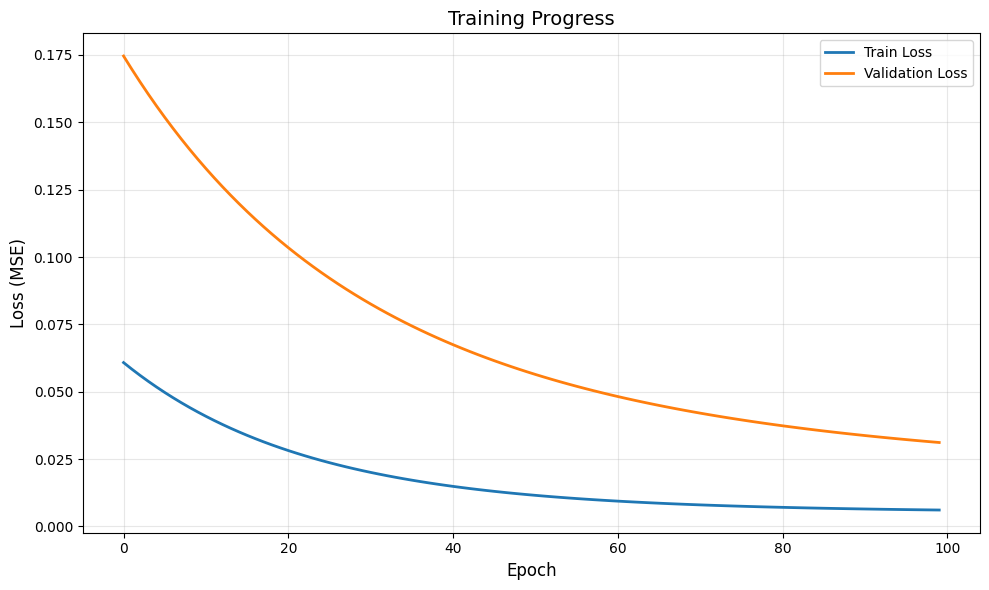

Training curve visualized!


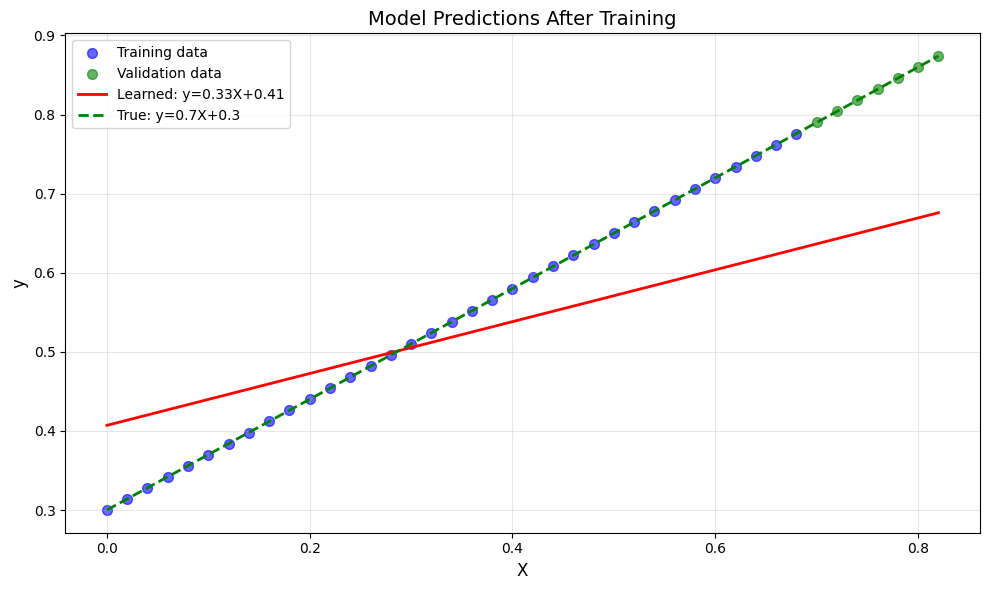

Predictions visualized!

Exercises

Exercise 1: Learning rate experiments
Tip: Create a loop over different learning rates and store results

Exercise 2: Optimizer comparison
Tip: optim.Adam(model.parameters(), lr=0.01)

Exercise 3: Early stopping
Tip: Track best_val_loss and use a patience counter

Exercise 4: Different loss functions
Tip: criterion = nn.L1Loss()

Exercise 5: Training analysis
Tip: Store param.grad.item() each epoch to plot gradients

Exercise 3 Complete!
Remember: Experiment, experiment, experiment!


In [1]:
"""
Exercise 3: Training Models
PyTorch Workflow Fundamentals - Module 2

This exercise covers:
- Setting up loss functions
- Using optimizers
- Implementing the 5-step training loop
- Tracking training progress
- Visualizing training curves

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# ============================================
# Part 1: Setup - Data and Model
# ============================================

print("=" * 60)
print("Part 1: Setup - Data and Model")
print("=" * 60)

# TODO: Create synthetic data
weight = 0.7
bias = 0.3
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

# TODO: Split data
train_split = int(0.7 * len(X))
val_split = int(0.85 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:val_split], y[train_split:val_split]

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")

# TODO: Create model


class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.weight * x + self.bias


model = LinearRegressionModel()

print(f"\nInitial parameters:")
print(f"  Weight: {model.weight.item():.4f} (true: {weight})")
print(f"  Bias: {model.bias.item():.4f} (true: {bias})")

# ============================================
# Part 2: Loss Function and Optimizer
# ============================================

print("\n" + "=" * 60)
print("Part 2: Loss Function and Optimizer")
print("=" * 60)

# TODO: Define loss function
criterion = nn.MSELoss()
print(f"Loss function: MSELoss (Mean Squared Error)")

# TODO: Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)
print(f"Optimizer: SGD (learning rate=0.01)")

# TODO: Calculate initial loss
with torch.no_grad():
    initial_pred = model(X_train)
    initial_loss = criterion(initial_pred, y_train)

print(f"\nInitial training loss: {initial_loss.item():.4f}")

# ============================================
# Part 3: The 5-Step Training Loop
# ============================================

print("\n" + "=" * 60)
print("Part 3: The 5-Step Training Loop")
print("=" * 60)

# TODO: Implement one training step
print("\nOne training step:")

# Step 1: Forward pass
y_pred = model(X_train)
print(f"1. Forward pass - predictions shape: {y_pred.shape}")

# Step 2: Calculate loss
loss = criterion(y_pred, y_train)
print(f"2. Calculate loss - loss value: {loss.item():.4f}")

# Step 3: Zero gradients
optimizer.zero_grad()
print(f"3. Zero gradients - cleared previous gradients")

# Step 4: Backward pass
loss.backward()
print(f"4. Backward pass - computed gradients")
print(f"   Weight gradient: {model.weight.grad.item():.4f}")
print(f"   Bias gradient: {model.bias.grad.item():.4f}")

# Step 5: Update parameters
optimizer.step()
print(f"5. Update parameters - optimizer stepped")

print(f"\nParameters after one step:")
print(f"  Weight: {model.weight.item():.4f}")
print(f"  Bias: {model.bias.item():.4f}")

# ============================================
# Part 4: Complete Training Loop
# ============================================

print("\n" + "=" * 60)
print("Part 4: Complete Training Loop")
print("=" * 60)

# TODO: Reinitialize model
model = LinearRegressionModel()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
val_losses = []

print(f"\nTraining for {epochs} epochs...")
print("-" * 60)

for epoch in range(epochs):
    ### Training
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    ### Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())

    ### Print progress
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

print(f"\nFinal parameters:")
print(f"  Weight: {model.weight.item():.4f} (true: {weight})")
print(f"  Bias: {model.bias.item():.4f} (true: {bias})")

# ============================================
# Part 5: Visualizing Training Progress
# ============================================

print("\n" + "=" * 60)
print("Part 5: Visualizing Training Progress")
print("=" * 60)

# TODO: Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=10)
plt.title('Training Progress', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Training curve visualized!")

# TODO: Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, c='b', s=50, alpha=0.6, label='Training data')
plt.scatter(X_val, y_val, c='g', s=50, alpha=0.6, label='Validation data')

with torch.no_grad():
    X_all = torch.cat([X_train, X_val])
    y_pred_all = model(X_all)
    plt.plot(X_all, y_pred_all, 'r-', linewidth=2,
             label=f"Learned: y={model.weight.item():.2f}X+{model.bias.item():.2f}")
    plt.plot(X_all, weight * X_all + bias, 'g--', linewidth=2,
             label=f"True: y={weight}X+{bias}")

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(fontsize=10)
plt.title('Model Predictions After Training', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Predictions visualized!")

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Learning rate experiments
print("\nExercise 1: Learning rate experiments")
# TODO: Train with lr=0.001, 0.01, 0.1
# TODO: Compare training curves
# TODO: Visualize all on same plot
print("Tip: Create a loop over different learning rates and store results")

# Exercise 2: Optimizer comparison
print("\nExercise 2: Optimizer comparison")
# TODO: Compare SGD vs Adam
# TODO: Compare convergence speed
# TODO: Compare final results
print("Tip: optim.Adam(model.parameters(), lr=0.01)")

# Exercise 3: Early stopping
print("\nExercise 3: Early stopping")
# TODO: Implement early stopping
# TODO: Stop when val loss doesn't improve for N epochs
# TODO: Save best model
print("Tip: Track best_val_loss and use a patience counter")

# Exercise 4: Loss functions
print("\nExercise 4: Different loss functions")
# TODO: Try MAE (L1Loss)
# TODO: Compare with MSE
# TODO: Discuss differences
print("Tip: criterion = nn.L1Loss()")

# Exercise 5: Training analysis
print("\nExercise 5: Training analysis")
# TODO: Plot gradient magnitudes during training
# TODO: Plot parameter updates
# TODO: Analyze convergence
print("Tip: Store param.grad.item() each epoch to plot gradients")

print("\n" + "=" * 60)
print("Exercise 3 Complete!")
print("Remember: Experiment, experiment, experiment!")
print("=" * 60)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# ============================================
# Part 1: Setup - Data and Model
# ============================================

print("=" * 60)
print("Part 1: Setup - Data and Model")
print("=" * 60)

# TODO: Create synthetic data
weight = 0.7
bias = 0.3
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

# TODO: Split data
train_split = int(0.7 * len(X))
val_split = int(0.85 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:val_split], y[train_split:val_split]

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")

# TODO: Create model


class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.weight * x + self.bias


model = LinearRegressionModel()

print(f"\nInitial parameters:")
print(f"  Weight: {model.weight.item():.4f} (true: {weight})")
print(f"  Bias: {model.bias.item():.4f} (true: {bias})")

Part 1: Setup - Data and Model
Train size: 35
Validation size: 7

Initial parameters:
  Weight: 0.3367 (true: 0.7)
  Bias: 0.1288 (true: 0.3)


# Exercise 1: Learning rate experiments
- TODO: Train with lr=0.001, 0.01, 0.1
- TODO: Compare training curves
- TODO: Visualize all on same plot

Part 2: Loss Function and Optimizer
Loss function: MSELoss (Mean Squared Error)

Initial training loss: 0.0922
Compare training curves with different learning rates

Training with learning rate: 0.001


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Training with learning rate: 0.01

Training with learning rate: 0.1


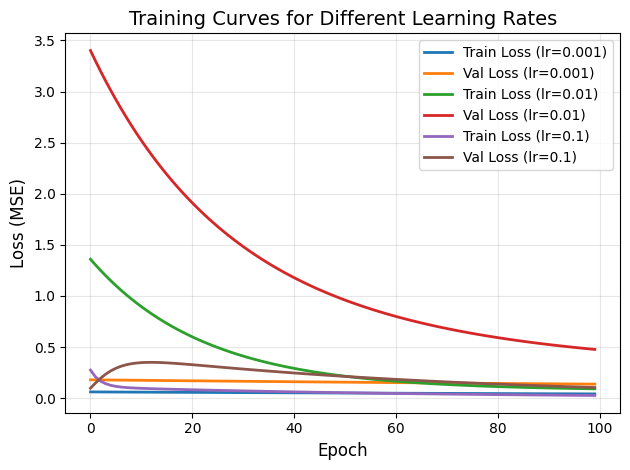

In [3]:
print("Part 2: Loss Function and Optimizer")
print("=" * 60)

# TODO: Define loss function
criterion = nn.MSELoss()
print(f"Loss function: MSELoss (Mean Squared Error)")

# # TODO: Define optimizer
# optimizer = optim.SGD(model.parameters(), lr=0.001)
# print(f"Optimizer: SGD (learning rate=0.001)")

# TODO: Calculate initial loss
with torch.no_grad():
    initial_pred = model(X_train)
    initial_loss = criterion(initial_pred, y_train)

print(f"\nInitial training loss: {initial_loss.item():.4f}")

print("Compare training curves with different learning rates")

s = [0.001, 0.01, 0.1]
for lr in s:
    print(f"\nTraining with learning rate: {lr}")
    model = LinearRegressionModel()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(100):
        # Training step
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Validation step
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

    plt.plot(train_losses, label=f'Train Loss (lr={lr})', linewidth=2)
    plt.plot(val_losses, label=f'Val Loss (lr={lr})', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=10)
plt.title('Training Curves for Different Learning Rates', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()  

# Exercise 2: Optimizer comparison
- TODO: Compare SGD vs Adam
- TODO: Compare convergence speed
- TODO: Compare final results


Exercise 2: Optimizer comparison - Convergence speed analysis

Training with optimizer: SGD
  Final train loss: 0.072914
  Final val loss: 0.026303
  Final weight: 1.5596 (true: 0.7)
  Final bias: -0.1948 (true: 0.3)

Training with optimizer: Adam
  Final train loss: 0.025063
  Final val loss: 0.104323
  Final weight: -0.0763 (true: 0.7)
  Final bias: 0.5685 (true: 0.3)


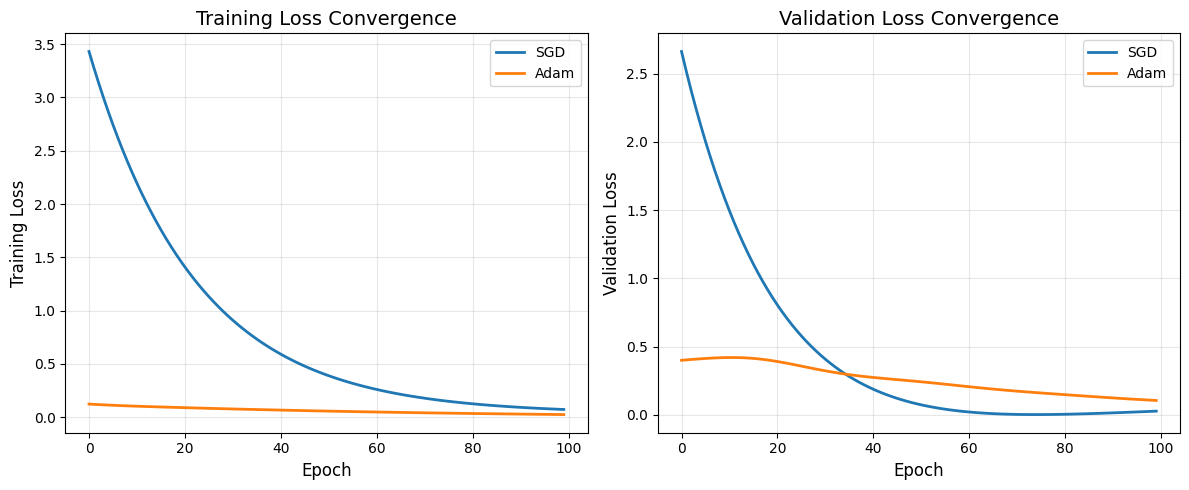


Convergence Speed Comparison Summary

SGD:
  Final train loss: 0.072914
  Final val loss: 0.026303
  Weight error: 0.859610
  Bias error: 0.494808

Adam:
  Final train loss: 0.025063
  Final val loss: 0.104323
  Weight error: 0.776259
  Bias error: 0.268462


In [5]:
print("Exercise 2: Optimizer comparison - Convergence speed analysis")
results = {} 

optimizers = {
    'SGD': optim.SGD,
    'Adam': optim.Adam
}   

for opt_name, opt_class in optimizers.items():
    print(f"\nTraining with optimizer: {opt_name}")
    model = LinearRegressionModel()
    optimizer = opt_class(model.parameters(), lr=0.01)

    train_losses = []
    val_losses = []

    for epoch in range(100):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

    results[opt_name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'weight': model.weight.item(),
        'bias': model.bias.item()
    }
    
    print(f"  Final train loss: {train_losses[-1]:.6f}")
    print(f"  Final val loss: {val_losses[-1]:.6f}")
    print(f"  Final weight: {model.weight.item():.4f} (true: {weight})")
    print(f"  Final bias: {model.bias.item():.4f} (true: {bias})")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for opt_name, data in results.items():
    plt.plot(data['train_losses'], label=f'{opt_name}', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.legend(fontsize=10)
plt.title('Training Loss Convergence', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for opt_name, data in results.items():
    plt.plot(data['val_losses'], label=f'{opt_name}', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.legend(fontsize=10)
plt.title('Validation Loss Convergence', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Convergence Speed Comparison Summary")
print("=" * 60)
for opt_name, data in results.items():
    print(f"\n{opt_name}:")
    print(f"  Final train loss: {data['final_train_loss']:.6f}")
    print(f"  Final val loss: {data['final_val_loss']:.6f}")
    print(f"  Weight error: {abs(data['weight'] - weight):.6f}")
    print(f"  Bias error: {abs(data['bias'] - bias):.6f}")

# Exercise 3: Early stopping
- TODO: Implement early stopping
- TODO: Stop when val loss doesn't improve for N epochs
- TODO: Save best model

Exercise 3: Early stopping implementation
Training with early stopping (patience=15)...
------------------------------------------------------------
Epoch   0: Train Loss = 0.5468, Val Loss = 0.9440, Patience = 0/15
Epoch  20: Train Loss = 0.2245, Val Loss = 0.4535, Patience = 0/15
Epoch  40: Train Loss = 0.0942, Val Loss = 0.2333, Patience = 0/15
Epoch  60: Train Loss = 0.0414, Val Loss = 0.1305, Patience = 0/15
Epoch  80: Train Loss = 0.0200, Val Loss = 0.0802, Patience = 0/15
Epoch 100: Train Loss = 0.0112, Val Loss = 0.0541, Patience = 0/15
Epoch 120: Train Loss = 0.0076, Val Loss = 0.0400, Patience = 0/15
Epoch 140: Train Loss = 0.0061, Val Loss = 0.0318, Patience = 0/15
Epoch 160: Train Loss = 0.0053, Val Loss = 0.0268, Patience = 0/15
Epoch 180: Train Loss = 0.0050, Val Loss = 0.0237, Patience = 0/15

Final parameters (best model):
  Weight: 1.0404 (true: 0.7)
  Bias: 0.1878 (true: 0.3)


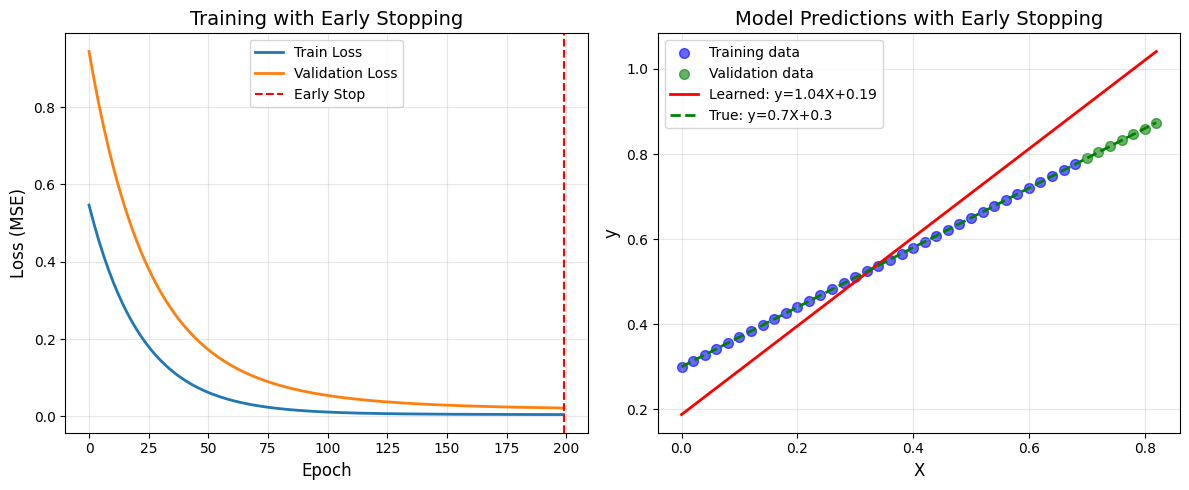


Early stopping implemented successfully!


In [6]:
print("Exercise 3: Early stopping implementation")

model = LinearRegressionModel()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 200
patience = 15 
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

print(f"Training with early stopping (patience={patience})...")
print("-" * 60)

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {
            'weight': model.weight.clone(),
            'bias': model.bias.clone()
        }
    else:
        patience_counter += 1
        
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}, Patience = {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best validation loss: {best_val_loss.item():.4f}")
        break

if best_model_state is not None:
    model.weight.data = best_model_state['weight']
    model.bias.data = best_model_state['bias']

print(f"\nFinal parameters (best model):")
print(f"  Weight: {model.weight.item():.4f} (true: {weight})")
print(f"  Bias: {model.bias.item():.4f} (true: {bias})")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.axvline(x=len(train_losses)-1, color='r', linestyle='--', label='Early Stop')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=10)
plt.title('Training with Early Stopping', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, c='b', s=50, alpha=0.6, label='Training data')
plt.scatter(X_val, y_val, c='g', s=50, alpha=0.6, label='Validation data')

with torch.no_grad():
    X_all = torch.cat([X_train, X_val])
    y_pred_all = model(X_all)
    plt.plot(X_all, y_pred_all, 'r-', linewidth=2,
             label=f"Learned: y={model.weight.item():.2f}X+{model.bias.item():.2f}")
    plt.plot(X_all, weight * X_all + bias, 'g--', linewidth=2,
             label=f"True: y={weight}X+{bias}")

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(fontsize=10)
plt.title('Model Predictions with Early Stopping', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEarly stopping implemented successfully!")

# Exercise 4: Loss functions
- TODO: Try MAE (L1Loss)
- TODO: Compare with MSE
- TODO: Discuss differences

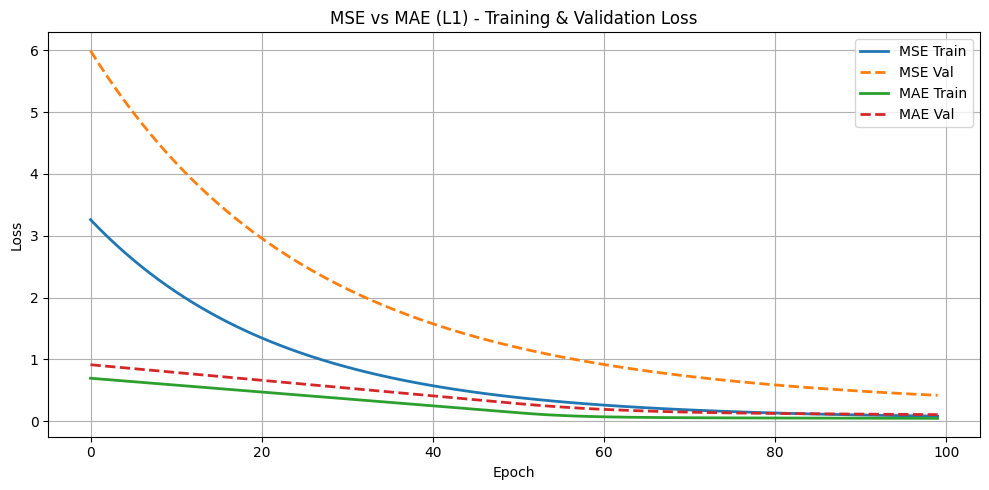

MSE: final train=0.083251, final val=0.419780, weight=-0.4301, bias=0.5126
MAE: final train=0.047408, final val=0.107331, weight=0.4314, bias=0.3968


In [11]:
epochs = 100
lr = 0.01
criterions = {'MSE': nn.MSELoss(), 'MAE': nn.L1Loss()}
history = {}

for name, crit in criterions.items():
    model_cmp = LinearRegressionModel()
    optimizer_cmp = optim.SGD(model_cmp.parameters(), lr=lr)

    train_ls = []
    val_ls = []
    for epoch in range(epochs):
        model_cmp.train()
        y_pred = model_cmp(X_train)
        loss = crit(y_pred, y_train)

        optimizer_cmp.zero_grad()
        loss.backward()
        optimizer_cmp.step()
        train_ls.append(loss.item())

        model_cmp.eval()
        with torch.no_grad():
            val_loss = crit(model_cmp(X_val), y_val)
            val_ls.append(val_loss.item())

    history[name] = {
        'train': train_ls,
        'val': val_ls,
        'weight': model_cmp.weight.item(),
        'bias': model_cmp.bias.item()
    }

# Plot training & validation curves for both losses
plt.figure(figsize=(10, 5))
for name, data in history.items():
    plt.plot(data['train'], label=f'{name} Train', linewidth=2)
    plt.plot(data['val'], label=f'{name} Val', linestyle='--', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MSE vs MAE (L1) - Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print summary and brief discussion
for name, data in history.items():
    print(f"{name}: final train={data['train'][-1]:.6f}, final val={data['val'][-1]:.6f}, weight={data['weight']:.4f}, bias={data['bias']:.4f}")


In [13]:
print("\nDiscussion:")
print("MAE (L1) penalizes absolute errors and is more robust to outliers; gradients are constant (except at 0), which can make convergence less smooth/slower. \nMSE penalizes large errors more strongly and often yields smoother, faster gradient-based convergence but is more sensitive to outliers.")


Discussion:
MAE (L1) penalizes absolute errors and is more robust to outliers; gradients are constant (except at 0), which can make convergence less smooth/slower. 
MSE penalizes large errors more strongly and often yields smoother, faster gradient-based convergence but is more sensitive to outliers.


# Exercise 5: Training analysis
- TODO: Plot gradient magnitudes during training
- TODO: Plot parameter updates
- TODO: Analyze convergence

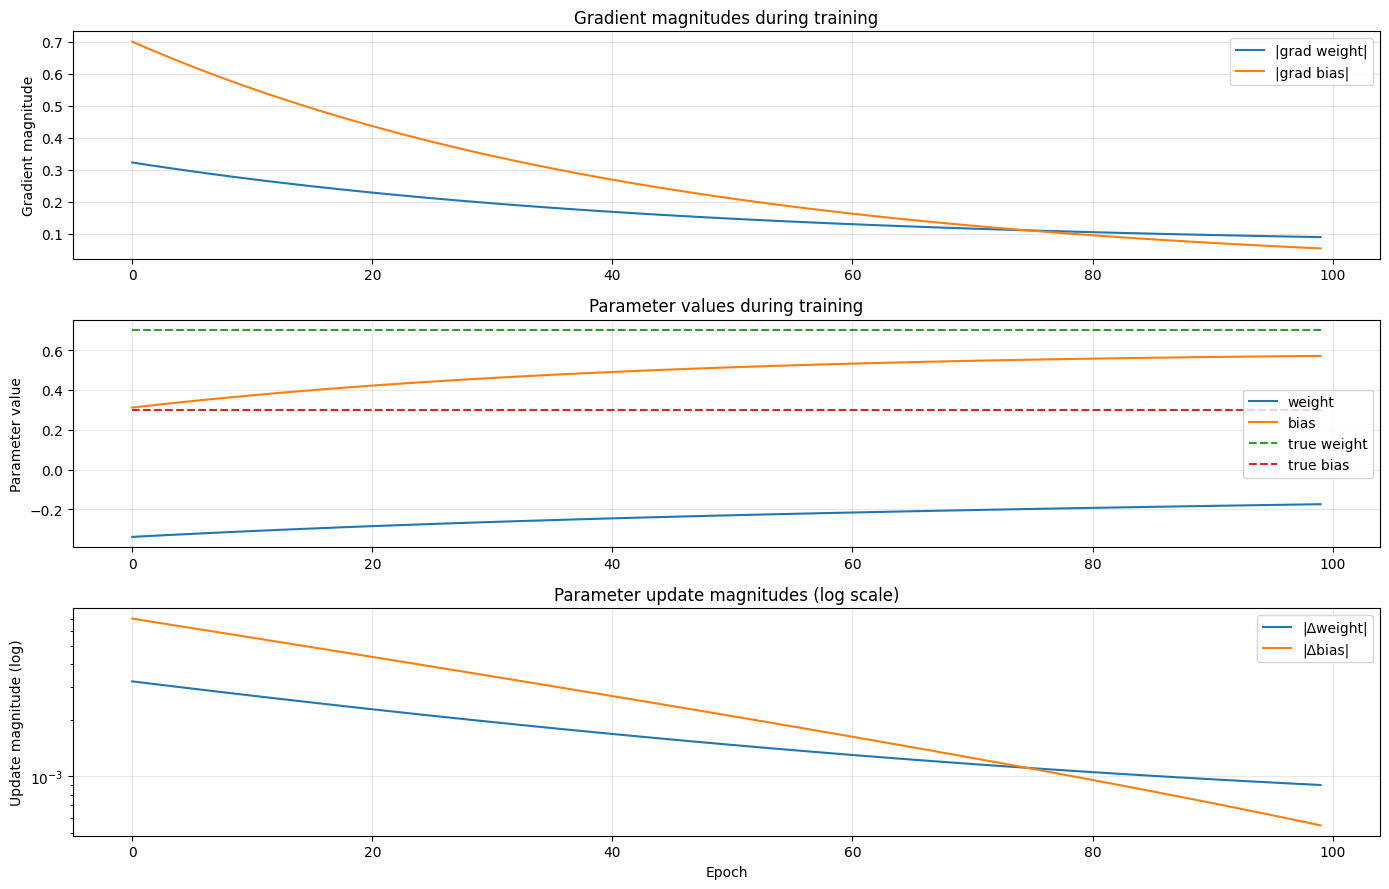

Final train loss: 0.031996, val loss: 0.156208
Final weight: -0.174254 (true: 0.7), bias: 0.570752 (true: 0.3)


In [18]:
model = LinearRegressionModel()           
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 100
gw_abs, gb_abs = [], []
w_vals, b_vals = [], []
w_updates, b_updates = [], []
train_ls, val_ls = [], []

for ep in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()

    # record gradient magnitudes (absolute)
    gw = model.weight.grad.item() if model.weight.grad is not None else 0.0
    gb = model.bias.grad.item() if model.bias.grad is not None else 0.0
    gw_abs.append(abs(gw))
    gb_abs.append(abs(gb))

    # record parameters before update
    w_before = model.weight.data.clone()
    b_before = model.bias.data.clone()

    optimizer.step()

    # record parameters after update and update magnitudes
    w_after = model.weight.data.clone()
    b_after = model.bias.data.clone()
    w_vals.append(w_after.item())
    b_vals.append(b_after.item())
    w_updates.append(abs((w_after - w_before).item()))
    b_updates.append(abs((b_after - b_before).item()))

    train_ls.append(loss.item())
    model.eval()
    with torch.no_grad():
        val_ls.append(criterion(model(X_val), y_val).item())

# Plots
plt.figure(figsize=(14, 9))

plt.subplot(3, 1, 1)
plt.plot(gw_abs, label='|grad weight|')
plt.plot(gb_abs, label='|grad bias|')
plt.ylabel('Gradient magnitude')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Gradient magnitudes during training')

plt.subplot(3, 1, 2)
plt.plot(w_vals, label='weight')
plt.plot(b_vals, label='bias')
plt.hlines(weight, 0, epochs-1, colors='C2', linestyles='--', label='true weight')
plt.hlines(bias, 0, epochs-1, colors='C3', linestyles='--', label='true bias')
plt.ylabel('Parameter value')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Parameter values during training')

plt.subplot(3, 1, 3)
plt.plot(w_updates, label='|Δweight|')
plt.plot(b_updates, label='|Δbias|')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Update magnitude (log)')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Parameter update magnitudes (log scale)')

plt.tight_layout()
plt.show()

# Brief numeric summary
print(f"Final train loss: {train_ls[-1]:.6f}, val loss: {val_ls[-1]:.6f}")
print(f"Final weight: {w_vals[-1]:.6f} (true: {weight}), bias: {b_vals[-1]:.6f} (true: {bias})")